In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn.cluster as cluster
from sklearn.decomposition import PCA

In [20]:
df = pd.read_csv("params_df.csv")
df.columns = ["country", "intercept", "tue", "wed", "thu", "fri", "sat", "sun", 
              "feb", "mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec",
              "hours_1", "hours_2", "hours_3", "hours_4", "hours_5"]
df.set_index(df.iloc[:, 0], inplace = True)
df.drop(df.columns[0], axis = 1, inplace = True)

months = ["feb", "mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"]
days = ["tue", "wed", "thu", "fri", "sat", "sun"]
hours = ["hours_1", "hours_2", "hours_3", "hours_4", "hours_5"]

In [24]:
def get_day_mean(df, day):
    if day =="mon":
        return df["intercept"] + df[hours].mean(axis = 1) + df[months].mean(axis = 1)
    return df["intercept"] + df[day] + df[hours].mean(axis = 1) + df[months].mean(axis = 1)
    
def get_month_mean(df, month):
    if month == "jan":
        return df["intercept"] + df[hours].mean(axis = 1) + df[days].mean(axis = 1)
    return df["intercept"] + df[month] + df[hours].mean(axis = 1) + df[days].mean(axis = 1)

def get_hour_mean(df, hour):
    if hour == "hours_0":
        return df["intercept"] + df[days].mean(axis = 1) + df[months].mean(axis = 1)
    return df["intercept"] + df[hour] + df[days].mean(axis = 1) + df[months].mean(axis = 1)

In [25]:
new_df = df.copy()
new_df["jan"] = get_month_mean(df, "jan")
new_df["mon"] = get_day_mean(df, "mon")
new_df["hours_0"] = get_hour_mean(df, "hours_0")
for day in days:
    new_df[day] = get_day_mean(df, day)
for month in months:
    new_df[month] = get_month_mean(df, month)
for hour in hours:
    new_df[hour] = get_hour_mean(df, hour)

new_df.drop("intercept", axis = 1, inplace = True)

In [36]:
true_months = ["jan", "feb", "mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"]
true_hours = ["hours_0", "hours_1", "hours_2", "hours_3", "hours_4", "hours_5"]
true_days = ["mon", "tue", "wed", "thu", "fri", "sat", "sun"]

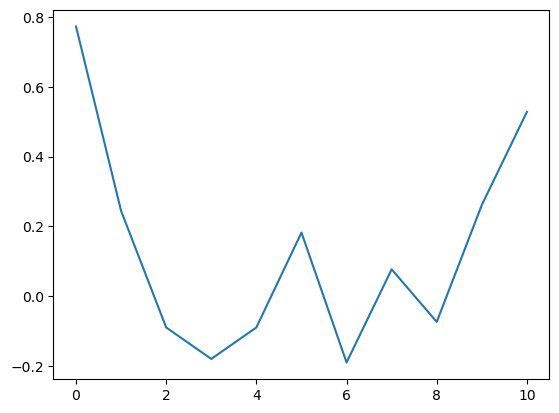

In [43]:
plt.plot(new_df[months][new_df.index == "POR"].to_numpy()[0])

In [47]:
new_df.to_csv( "best_coefficients.csv", index = True)

In [55]:
X = new_df.to_numpy().astype(float)
pca = PCA(n_components = 3)
pca_res = pca.fit(X)
X_reduced = pca.transform(X)

<BarContainer object of 25 artists>

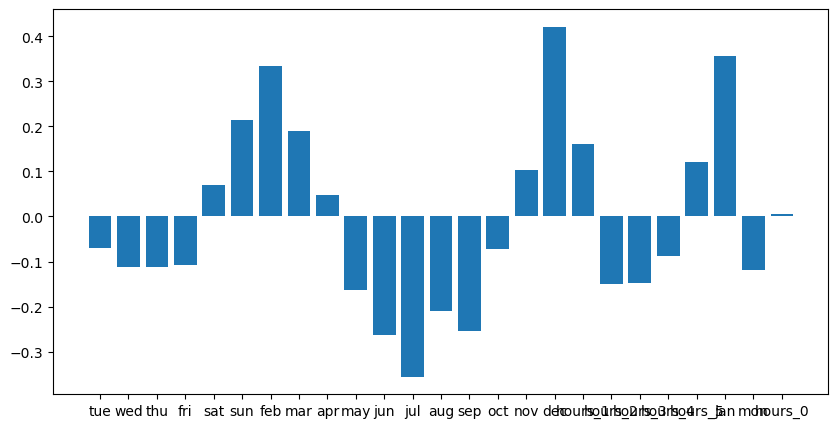

In [71]:
fig, ax = plt.subplots(figsize = (10, 5))
plt.bar(new_df.columns, height =  pca_res.components_[0, :])

<BarContainer object of 25 artists>

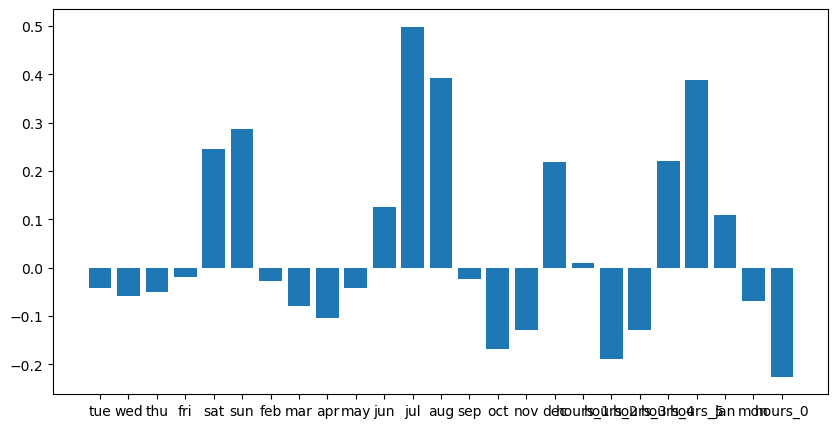

In [72]:
fig, ax = plt.subplots(figsize = (10, 5))
plt.bar(new_df.columns, height =  pca_res.components_[1, :])

<BarContainer object of 25 artists>

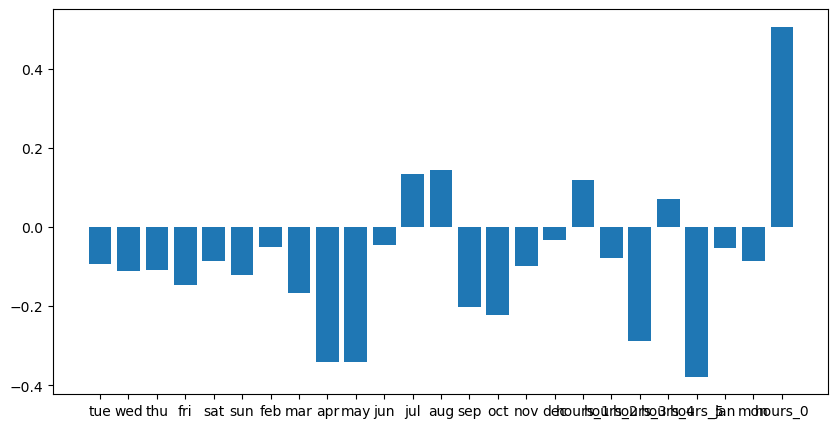

In [75]:
fig, ax = plt.subplots(figsize = (10, 5))
plt.bar(new_df.columns, height =  pca_res.components_[2, :])

c:\Users\kam224\AppData\Local\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\kam224\AppData\Local\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\kam224\AppData\Local\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\kam224\AppData\Local\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:14

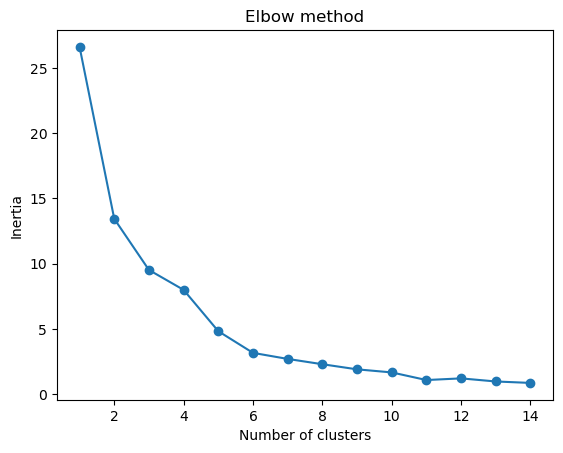

In [97]:
inertias = []
for i in range(1,15):
    kmeans = cluster.KMeans(n_clusters=i)
    kmeans.fit(X_reduced)
    inertias.append(kmeans.inertia_)

plt.plot(range(1,15), inertias, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show() 

In [96]:
df.index[clustering.labels_ == 2]

Index(['BEL', 'DEU', 'AUT', 'DNK', 'CZE', 'POL', 'SVK', 'ROU'], dtype='str', name='country')

c:\Users\kam224\AppData\Local\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


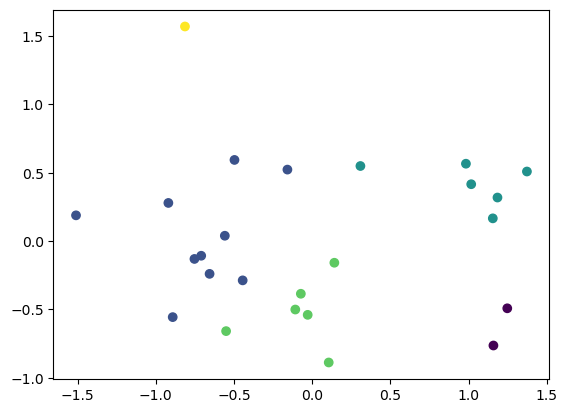

In [98]:
clustering = cluster.KMeans(n_clusters = 5)
clustering = clustering.fit(X)
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c = clustering.labels_)

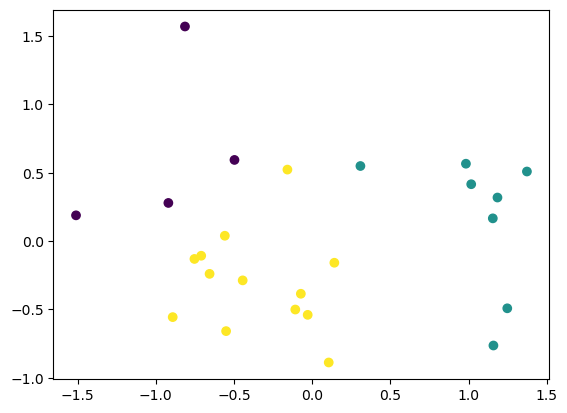

In [79]:
X_clustered.shape

(25, 3)

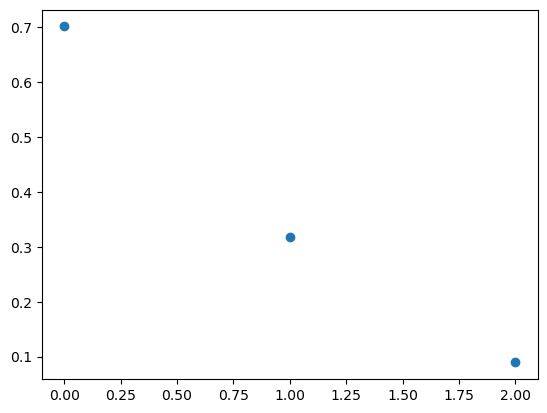

In [60]:
plt.scatter(x = range(3), y= pca_res.explained_variance_)